In [3]:
#!/usr/bin/env python3
# plot_longbench_rank_curves.py

import argparse
from pathlib import Path
import math

import pandas as pd
import matplotlib.pyplot as plt

# No seaborn; no explicit colors (use matplotlib defaults).

def _nice_grid(n: int, max_cols: int = 4):
    """Return (nrows, ncols) for n panels."""
    if n <= 0:
        return (1, 1)
    ncols = min(max_cols, max(1, int(math.ceil(math.sqrt(n)))))
    nrows = int(math.ceil(n / ncols))
    return nrows, ncols

def plot_by_task(df_fam: pd.DataFrame, family: str, out_path: Path, max_cols: int = 4, presses=None):
    # panels = tasks, lines = presses
    tasks = sorted(df_fam["task"].unique().tolist())
    if presses is None:
        presses = sorted(df_fam["press"].unique().tolist())

    # ---- 加入map: press -> label, color ----
    press_labels = [
        ("snapkv", "SnapKV"),
        ("memory_snapkv", "SnapKV+Memory"),
        ("query_indexer_max_mode", "Indexer only"),
        ("memory_query_indexer_max", "IndexMem"),
    ]
    colors = [
        "#5699F1",  # red
        "#634BDD",  # blue
    ]
    # 构建press顺序和label映射
    label_map = {press: label for press, label in press_labels}
    color_map = {press: colors[i % len(colors)] for i, (press, _) in enumerate(press_labels)}
    # ---------------------------------------

    # —— 强制横排，如图所示：nrows=1, ncols=4（按task数量横向排满）
    nrows = 1
    ncols = len(tasks)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, dpi=200)

    # axes 是 array 还是单个, 做兼容
    if ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax_i, task in enumerate(tasks):
        ax = axes[ax_i]
        d_task = df_fam[df_fam["task"] == task]

        for press in presses:
            d_line = d_task[d_task["press"] == press].sort_values("cr")
            if d_line.empty:
                continue
            label = label_map.get(press, press)
            color = color_map.get(press, None)
            ax.plot(d_line["cr"], d_line["avg_score"], marker="o", linewidth=1.5, label=label, color=color)

        ax.set_title(task)
        ax.set_xlabel("Compression Ratio")
        ax.set_ylabel("Average Score")
        ax.grid(True, linewidth=0.5, alpha=0.5)

    for j in range(len(tasks), len(axes)):
        axes[j].axis("off")

    # 汇总 legend，避免有的panel没有line
    label2handle = {}
    for k in range(len(tasks)):
        hs, ls = axes[k].get_legend_handles_labels()
        for h, l in zip(hs, ls):
            label2handle.setdefault(l, h)
    if label2handle:
        labels = list(label2handle.keys())
        handles = [label2handle[l] for l in labels]
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), len(labels)), frameon=True)

    # fig.suptitle(f"LongBench curves (by task) | family={family}", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(out_path, dpi=400)
    # plt.close(fig)

def plot_by_press(df_fam: pd.DataFrame, family: str, out_path: Path, max_cols: int = 4):
    # panels = presses, lines = tasks
    presses = sorted(df_fam["press"].unique().tolist())
    tasks = sorted(df_fam["task"].unique().tolist())
    nrows, ncols = _nice_grid(len(presses), max_cols=max_cols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols,  nrows), sharex=True)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax_i, press in enumerate(presses):
        ax = axes[ax_i]
        d_press = df_fam[df_fam["press"] == press]

        for task in tasks:
            d_line = d_press[d_press["task"] == task].sort_values("cr")
            if d_line.empty:
                continue
            ax.plot(d_line["cr"], d_line["avg_score"], marker="o", linewidth=1.5, label=task)

        ax.set_title(press)
        ax.set_xlabel("cr")
        ax.set_ylabel("avg_score")
        ax.grid(True, linewidth=0.5, alpha=0.5)

    for j in range(len(presses), len(axes)):
        axes[j].axis("off")

    # global legend (tasks)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        # put legend outside to avoid clutter
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6), frameon=True)

    fig.suptitle(f"LongBench curves (by press) | family={family}", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(out_path, dpi=400)
    plt.close(fig)


def plot_llama_focus_4tasks(df: pd.DataFrame, out_path: Path):
    family = "llama3-8b"
    tasks_keep = ["hotpotqa", "multifieldqa_en", "trec", "triviaqa"]
    press_drop = "query_indexer_max_mode"

    # 自定义颜色和 label，顺序明确
    # 注意：press_labels 顺序即为 legend label 顺序
    press_labels = [
        ("memory_query_indexer_max", "IndexMem"),
        ("expected_attention", "Expected Attention"),
        ("pyramidkv", "PyramidKV"),
        ("snapkv", "SnapKV"),
        ("tova", "TOVA"),
    ]
    colors = [
        "#001BB7",  # blue
        "#A199F0",  # red
        "#BFE3FF",  # orange
        "#009090",  # purple
        "#63E2CC",  # green
    ]

    # 构建press顺序和label映射
    press_order = [press for press, _ in press_labels]
    label_map = {press: label for press, label in press_labels}
    color_map = {press: colors[i % len(colors)] for i, (press, _) in enumerate(press_labels)}

    d = df[(df["family"] == family) & (df["task"].isin(tasks_keep)) & (df["press"] != press_drop)].copy()
    if d.empty:
        print(f"[WARN] llama focus plot skipped: no data for family={family} tasks={tasks_keep} excluding {press_drop}")
        return

    tasks = tasks_keep  # 按你指定顺序出panel

    fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, dpi=200)
    axes = axes.flatten()

    for i, task in enumerate(tasks):
        ax = axes[i]
        d_task = d[d["task"] == task]

        # 只按press_labels中有的顺序画
        for press in press_order:
            d_line = d_task[d_task["press"] == press].sort_values("cr")
            if d_line.empty:
                continue
            color = color_map[press]
            label = label_map[press]
            ax.plot(d_line["cr"], d_line["avg_score"], marker="o", linewidth=1.8, label=label, color=color)

        ax.set_title(task)
        ax.set_xlabel("Compression Ratio")
        ax.set_ylabel("Average Score")
        ax.grid(True, linewidth=0.5, alpha=0.5)

    # legend顺序也直接给定
    handles_labels = []
    # 在axes[0] 找到所有存在的press
    for press in press_order:
        label = label_map[press]
        h = None
        # Find the handle in axes[0] for corresponding label
        for handle, l in zip(*axes[0].get_legend_handles_labels()):
            if l == label:
                h = handle
                break
        if h is not None:
            handles_labels.append( (h, label) )
    if handles_labels:
        handles, labels = zip(*handles_labels)
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 5), frameon=True)

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    fig.savefig(out_path, dpi=400)
    # plt.close(fig)

    print(f"[OK] saved: {out_path}")


def plot_memory_compare_by_task(df: pd.DataFrame, out_dir: Path, family: str = None, max_cols: int = 4):
    # 只画 memory 系列 + memory_query_indexer_max
    memory_presses = ["memory_query_indexer_max", "memory_EA", "memory_snapkv", "memory_keydiff"]

    d = df[df["press"].isin(memory_presses)].copy()
    if family is not None:
        d = d[d["family"] == family].copy()

    if d.empty:
        print(f"[WARN] memory compare skipped: no rows for presses={memory_presses} family={family}")
        return

    fams = sorted(d["family"].unique().tolist())
    for fam in fams:
        d_fam = d[d["family"] == fam]
        # 🔍 debug：确保不止一条线
        # print(f"[DEBUG] memory_compare family={fam} presses={sorted(d_fam['press'].unique().tolist())}")

        out_path = out_dir / f"longbench_{fam}_memory_compare_by_task.png"
        # 传入固定 presses 顺序，保证四条线都被尝试画出来
        plot_by_task(d_fam, fam, out_path, max_cols=max_cols, presses=memory_presses)
        
        # print(f"[OK] saved: {out_path}")



def plot_llama_snapkv_4tasks(df: pd.DataFrame, out_dir: Path, max_cols: int = 4):
    family = "llama3-8b"
    tasks_keep = ["lcc", "musique", "passage_count", "triviaqa"]
    presses = ["snapkv", "memory_snapkv"]

    d = df[(df["family"] == family) &
           (df["task"].isin(tasks_keep)) &
           (df["press"].isin(presses))].copy()

    if d.empty:
        print(f"[WARN] llama snapkv 4tasks skipped: no rows for family={family}, tasks={tasks_keep}, presses={presses}")
        return

    # 保证子图顺序按你指定 tasks_keep
    d["task"] = pd.Categorical(d["task"], categories=tasks_keep, ordered=True)
    d = d.sort_values(["task", "press", "cr"])

    out_path = out_dir / f"longbench_{family}_snapkv_vs_memory_4tasks.svg"
    plot_by_task(d, family, out_path, max_cols=max_cols, presses=presses)
    # print(f"[OK] saved: {out_path}")


def plot_mistral_indexer_4tasks(df: pd.DataFrame, out_dir: Path, max_cols: int = 4):
    family = "mistral-7b"
    tasks_keep = ["multi_news", "passage_retrieval_zh", "qasper", "trec"]
    presses = ["query_indexer_max_mode", "memory_query_indexer_max"]

    d = df[(df["family"] == family) &
           (df["task"].isin(tasks_keep)) &
           (df["press"].isin(presses))].copy()

    if d.empty:
        print(f"[WARN] mistral indexer 4tasks skipped: no rows for family={family}, tasks={tasks_keep}, presses={presses}")
        return

    # 保证子图顺序按你指定的 tasks_keep
    d["task"] = pd.Categorical(d["task"], categories=tasks_keep, ordered=True)
    d = d.sort_values(["task", "press", "cr"])
    out_path = out_dir / f"longbench_{family}_indexer_vs_memory_4tasks.svg"
    plot_by_task(d, family, out_path, max_cols=max_cols, presses=presses)
    # print(f"[OK] saved: {out_path}")

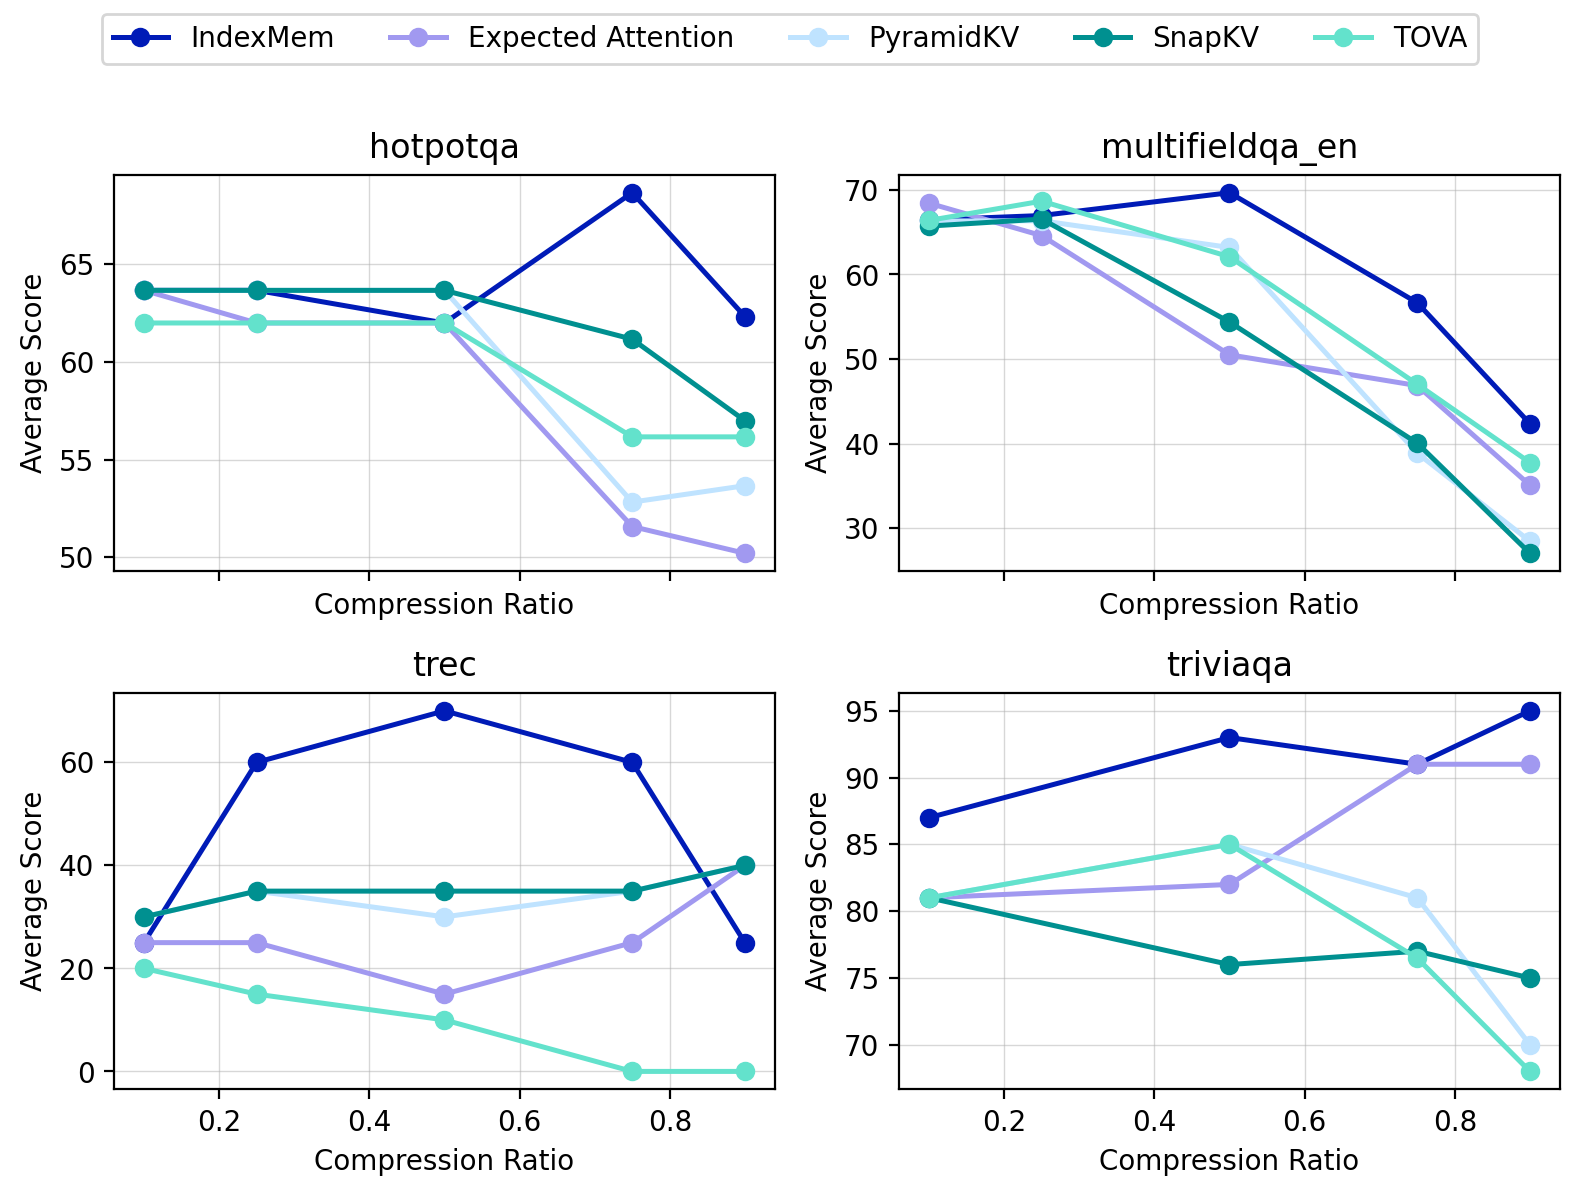

[OK] saved: /aifs4su/guhao/KVCache/kvpress/evaluation/plots_longbench/longbench_llama3-8b.png


In [ ]:
# Run as if CLI:
# --csv /aifs4su/guhao/KVCache/kvpress/evaluation/results_longbench_frac0.1/rank_by_task_intersection.csv \
# --out_dir /aifs4su/guhao/KVCache/kvpress/evaluation/plots_longbench \
# --max_cols 5 \
# --llama_focus

df = pd.read_csv("/aifs4su/guhao/KVCache/kvpress/evaluation/results_longbench_frac0.1/rank_by_task_intersection.csv")
need_cols = {"family", "task", "cr", "press", "avg_score"}
missing = need_cols - set(df.columns)
if missing:
    raise SystemExit(f"[ERROR] missing columns in csv: {sorted(missing)}")

df["cr"] = df["cr"].astype(float)
df["avg_score"] = df["avg_score"].astype(float)

out_dir = Path("/aifs4su/guhao/KVCache/kvpress/evaluation/plots_longbench")
out_dir.mkdir(parents=True, exist_ok=True)

families = sorted(df["family"].unique().tolist())
# for fam in families:
#     d = df[df["family"] == fam]
#     if d.empty:
#         continue

#     out1 = out_dir / f"longbench_{fam}_by_task.png"
#     out2 = out_dir / f"longbench_{fam}_by_press.png"

#     plot_by_task(d, fam, out1, max_cols=5)
#     plot_by_press(d, fam, out2, max_cols=5)

#     print(f"[OK] saved: {out1}")
#     print(f"[OK] saved: {out2}")

# llama_focus is enabled
out_focus = out_dir / "longbench.svg"
plot_llama_focus_4tasks(df, out_focus)

In [ ]:
# Equivalent of CLI:
# --csv /aifs4su/guhao/KVCache/kvpress/evaluation/results_longbench_frac0.1/rank_by_task_intersection_memory.csv \
# --out_dir ./plots_memory_compare \
# --memory_compare

csv_path = "/aifs4su/guhao/KVCache/kvpress/evaluation/rank_by_task_intersection_memory.csv"
out_dir = Path("./plots_memory_compare")
out_dir.mkdir(parents=True, exist_ok=True)
max_cols = 4  # or leave as default

df = pd.read_csv(csv_path)
need_cols = {"family", "task", "cr", "press", "avg_score"}
missing = need_cols - set(df.columns)
if missing:
    raise SystemExit(f"[ERROR] missing columns in csv: {sorted(missing)}")

df["cr"] = df["cr"].astype(float)
df["avg_score"] = df["avg_score"].astype(float)

# Only do the memory_compare plotting
# plot_llama_snapkv_4tasks(df, out_dir, max_cols=max_cols)
plot_mistral_indexer_4tasks(df, out_dir, max_cols=max_cols)

In [17]:
max_budget = [512, 1024, 1536, 2048]

aime25_total = 30
aime25_baseline = 9
aime25_decode_snapkv = [1, 3, 4, 7]
aime25_decode_tova = [2, 3, 5, 8]
aime25_decode_indexer = [5, 6, 8, 9]



math500_total = 500
math500_baseline = 435
math500_decode_snapkv = [238, 356, 407, 414]
math500_decode_tova = [268, 386, 412, 429]
math500_decode_indexer = [310, 405, 424, 430]



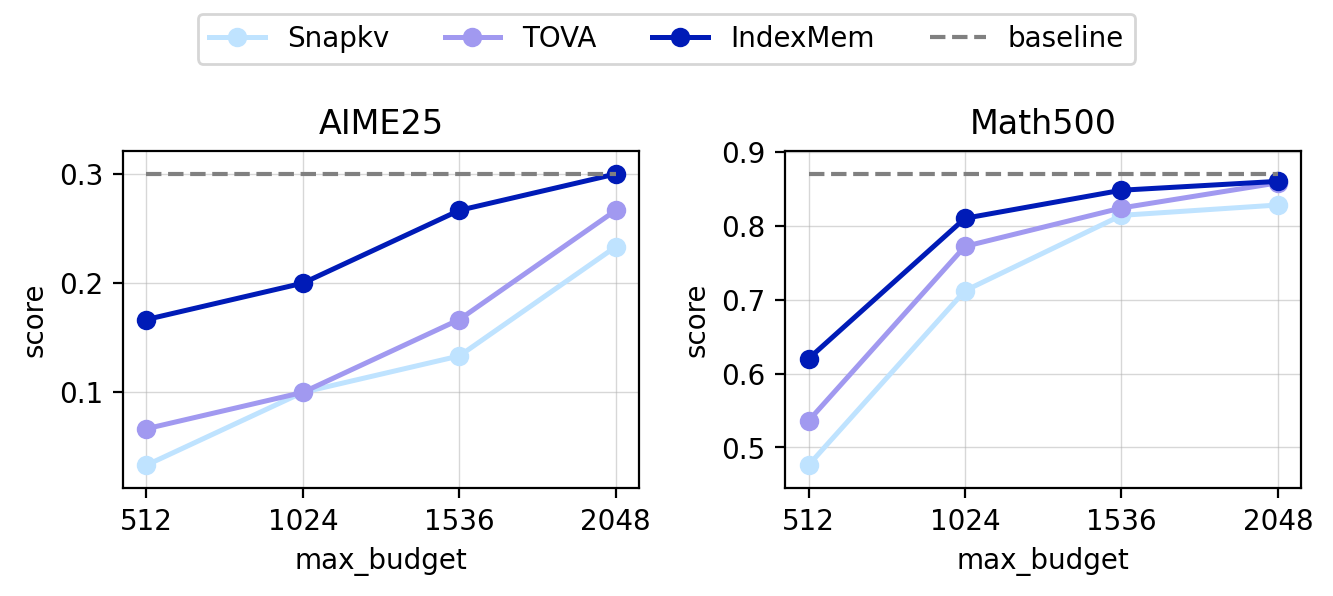

In [39]:
# 2*1 并排折线图（score = xxx / total）
colors = [
    "#BFE3FF",  # orange
    "#A199F0",  # red
    "#001BB7",  # blue
    "#009090",  # purple
    "#63E2CC",  # green
]

fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=200, sharey=False)

def _plot_panel(ax, title, total, baseline, series):
    all_scores = [baseline / total]
    for i, (name, values) in enumerate(series.items()):
        scores = [v / total for v in values]
        all_scores.extend(scores)
        ax.plot(
            max_budget,
            scores,
            marker="o",
            linewidth=1.8,
            label=name,
            color=colors[i % len(colors)],
        )
    ax.plot(
        max_budget,
        [baseline / total] * len(max_budget),
        linestyle="--",
        color="grey",
        linewidth=1.5,
        label="baseline",
    )
    ymin = min(all_scores)
    ymax = max(all_scores)
    pad = (ymax - ymin) * 0.08 if ymax > ymin else 0.02
    ax.set_ylim(max(0.0, ymin - pad), min(1.0, ymax + pad))
    ax.set_xticks(max_budget)
    x_min = min(max_budget)
    x_max = max(max_budget)
    x_pad = (x_max - x_min) * 0.05
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_title(title)
    ax.set_xlabel("max_budget")
    ax.set_ylabel("score")
    ax.grid(True, linewidth=0.5, alpha=0.5)

_plot_panel(
    axes[0],
    "AIME25",
    aime25_total,
    aime25_baseline,
    {
        "Snapkv": aime25_decode_snapkv,
        "TOVA": aime25_decode_tova,
        "IndexMem": aime25_decode_indexer,
    },
)

_plot_panel(
    axes[1],
    "Math500",
    math500_total,
    math500_baseline,
    {
        "Snapkv": math500_decode_snapkv,
        "TOVA": math500_decode_tova,
        "IndexMem": math500_decode_indexer,
    },
)

# 统一 legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=True)
fig.tight_layout(rect=[0, 0, 0.98, 0.88])
plt.savefig("aime25_math500.png", dpi=400)
plt.show()
